# Week 1 Lab Exercise — Python, NumPy, Matplotlib & Pandas
35 questions, 2 marks each

## Section A — Python (Q1–Q10)

**Q1.** Swap the values of two variables without using a third variable.

In [4]:
# using tuple unpacking to swap without a temp variable
a, b = 5, 10
a, b = b, a
print(a, b)

10 5


**Q2.** Write a function `is_prime(n)` that returns True if n is prime, else False.

In [41]:
# check divisibility only up to sqrt(n) for efficiency
def is_prime(n):
    if n < 2:
        return False
    for i in range(2, int(n ** 0.5) + 1):
        if n % i == 0:
            return False
    return True

for n in [1, 2, 15, 17, 20, 23]:
    print(n, is_prime(n))

1 False
2 True
15 False
17 True
20 False
23 True


**Q3.** Print the Fibonacci sequence up to n terms using a loop.

In [6]:
# build the sequence iteratively, starting from 0 and 1
def fibonacci(n):
    seq = []
    x, y = 0, 1
    for i in range(n):
        seq.append(x)
        x, y = y, x + y
    return seq

print(fibonacci(10))

[0, 1, 1, 2, 3, 5, 8, 13, 21, 34]


**Q4.** Return a new list with duplicates removed, preserving original order.

In [7]:
# track seen values with a set while keeping the original order
def remove_duplicates(items):
    seen = set()
    result = []
    for x in items:
        if x not in seen:
            seen.add(x)
            result.append(x)
    return result

print(remove_duplicates([1, 2, 2, 3, 1, 4, 3, 5]))

[1, 2, 3, 4, 5]


**Q5.** Count vowels, consonants, digits, and spaces in a given string.

In [8]:
# classify each character in a single pass
def count_chars(text):
    vowels = consonants = digits = spaces = 0
    for ch in text:
        low = ch.lower()
        if low in "aeiou":
            vowels += 1
        elif low.isalpha():
            consonants += 1
        elif ch.isdigit():
            digits += 1
        elif ch == " ":
            spaces += 1
    return vowels, consonants, digits, spaces

s = "Hello World 123"
print(count_chars(s))

(3, 7, 3, 2)


**Q6.** Write `multiply(*args)` that returns the product of any number of arguments.

In [9]:
# use *args to accept a variable number of numbers
def multiply(*args):
    result = 1
    for n in args:
        result *= n
    return result

print(multiply(2, 3, 4))
print(multiply(5, 6))

24
30


**Q7.** Dictionary comprehension mapping each character in a string to its frequency.

In [10]:
# count occurrences of each character with a comprehension
s = "programming"
freq = {ch: s.count(ch) for ch in s}
print(freq)

{'p': 1, 'r': 2, 'o': 1, 'g': 2, 'a': 1, 'm': 2, 'i': 1, 'n': 1}


**Q8.** Given a list of employee dicts (name, department, salary), find the employee with the highest salary.

In [11]:
employees = [
    {"name": "Ali", "department": "Sales", "salary": 52000},
    {"name": "Sara", "department": "IT", "salary": 61000},
    {"name": "Omar", "department": "Sales", "salary": 58000}
]
# max() with a key function finds the dict with the highest salary
top = max(employees, key=lambda e: e["salary"])
print(top)

{'name': 'Sara', 'department': 'IT', 'salary': 61000}


**Q9.** Check whether a given string is a palindrome, ignoring case and spaces.

In [12]:
# strip spaces and lowercase before comparing to its reverse
def is_palindrome(s):
    clean = s.replace(" ", "").lower()
    return clean == clean[::-1]

print(is_palindrome("Nurses Run"))
print(is_palindrome("Hello World"))

True
False


**Q10.** Use a lambda function with `filter()` to extract all odd numbers from a list.

In [13]:
nums = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
odds = list(filter(lambda x: x % 2 != 0, nums))
print(odds)

[1, 3, 5, 7, 9]


## Section B — NumPy (Q11–Q25)

In [14]:
import numpy as np

**Q11.** Create a 1D array of integers from 1 to 30 and reshape it into a 5x6 matrix.

In [15]:
arr = np.arange(1, 31).reshape(5, 6)
print(arr)

[[ 1  2  3  4  5  6]
 [ 7  8  9 10 11 12]
 [13 14 15 16 17 18]
 [19 20 21 22 23 24]
 [25 26 27 28 29 30]]


**Q12.** Create a 6x6 identity matrix and replace its diagonal with [1,2,3,4,5,6].

In [16]:
mat = np.eye(6)
np.fill_diagonal(mat, [1, 2, 3, 4, 5, 6])
print(mat)

[[1. 0. 0. 0. 0. 0.]
 [0. 2. 0. 0. 0. 0.]
 [0. 0. 3. 0. 0. 0.]
 [0. 0. 0. 4. 0. 0.]
 [0. 0. 0. 0. 5. 0.]
 [0. 0. 0. 0. 0. 6.]]


**Q13.** Given 25 random integers between 1 and 100, find the sum, mean, and standard deviation.

In [17]:
np.random.seed(1)
arr = np.random.randint(1, 100, 25)
print(arr)
print("sum:", arr.sum())
print("mean:", arr.mean())
print("std:", arr.std())

[38 13 73 10 76  6 80 65 17  2 77 72  7 26 51 21 19 85 12 29 30 15 51 69
 88]
sum: 1032
mean: 41.28
std: 28.881163411469423


**Q14.** Given a (4,4) array, extract the diagonal elements with `np.diag()` and compute their sum.

In [18]:
arr = np.arange(1, 17).reshape(4, 4)
diag = np.diag(arr)
print(diag)
print("sum:", diag.sum())

[ 1  6 11 16]
sum: 34


**Q15.** Two (3,3) arrays — show element-wise multiplication (`*`) vs matrix multiplication (`@`).

In [19]:
a = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])
b = np.array([[9, 8, 7], [6, 5, 4], [3, 2, 1]])
print("element-wise:\n", a * b)
print("matrix product:\n", a @ b)

element-wise:
 [[ 9 16 21]
 [24 25 24]
 [21 16  9]]
matrix product:
 [[ 30  24  18]
 [ 84  69  54]
 [138 114  90]]


**Q16.** Given daily temperatures for a month, use boolean masking to find days above 35°C and count them.

In [20]:
np.random.seed(2)
temps = np.random.randint(20, 45, 30)
hot_days = temps[temps > 35]
print(hot_days)
print("count:", hot_days.size)

[42 38 37 41 40 40 39]
count: 7


**Q17.** Normalize an array (scale all values to 0-1) using (x - min) / (max - min).

In [21]:
arr = np.array([10, 20, 30, 40, 50])
normalized = (arr - arr.min()) / (arr.max() - arr.min())
print(normalized)

[0.   0.25 0.5  0.75 1.  ]


**Q18.** Given a (5,3) array of 5 students' marks in 3 subjects, compute total and average marks per student.

In [22]:
marks = np.array([[80, 70, 90], [60, 65, 70], [95, 85, 90], [55, 60, 58], [72, 78, 81]])
total = marks.sum(axis=1)
average = marks.mean(axis=1)
print("total:", total)
print("average:", average)

total: [240 195 270 173 231]
average: [80.         65.         90.         57.66666667 77.        ]


**Q19.** Use `np.where()` to replace even numbers with -1 and keep odd numbers unchanged.

In [23]:
arr = np.arange(1, 11)
result = np.where(arr % 2 == 0, -1, arr)
print(result)

[ 1 -1  3 -1  5 -1  7 -1  9 -1]


**Q20.** Create a 4x4 matrix with `arange().reshape()` and compute its transpose, determinant, and inverse.

In [24]:
arr = np.arange(1, 17).reshape(4, 4).astype(float)
arr += np.eye(4)  # nudge values so the matrix is invertible
print("transpose:\n", arr.T)
det = np.linalg.det(arr)
print("determinant:", det)
if det != 0:
    print("inverse:\n", np.linalg.inv(arr))

transpose:
 [[ 2.  5.  9. 13.]
 [ 2.  7. 10. 14.]
 [ 3.  7. 12. 15.]
 [ 4.  8. 12. 17.]]
determinant: -44.99999999999996
inverse:
 [[-2.22222222e-01 -6.66666667e-01 -1.11111111e-01  4.44444444e-01]
 [-6.00000000e-01  6.00000000e-01 -2.00000000e-01  1.37456184e-16]
 [ 2.22222222e-02 -1.33333333e-01  7.11111111e-01 -4.44444444e-01]
 [ 6.44444444e-01  1.33333333e-01 -3.77777778e-01  1.11111111e-01]]


**Q21.** Given two 1D vectors, compute their dot product manually with a loop and verify against `np.dot()`.

In [25]:
v1 = np.array([1, 2, 3, 4])
v2 = np.array([5, 6, 7, 8])
manual = 0
for i in range(len(v1)):
    manual += v1[i] * v2[i]
print("manual:", manual)
print("np.dot:", np.dot(v1, v2))

manual: 70
np.dot: 70


**Q22.** Read 10 numbers from user input, convert to a NumPy array, print the sorted array and its median.

In [26]:
# simulated input list in place of interactive input() for notebook execution
values = [23, 5, 67, 12, 89, 34, 1, 45, 78, 10]
arr = np.array(values)
print("sorted:", np.sort(arr))
print("median:", np.median(arr))

sorted: [ 1  5 10 12 23 34 45 67 78 89]
median: 28.5


**Q23.** Given a (3,4) array, use fancy indexing to select rows [0, 2] and columns [1, 3] together.

In [27]:
arr = np.arange(1, 13).reshape(3, 4)
print(arr)
selection = arr[np.ix_([0, 2], [1, 3])]
print(selection)

[[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]]
[[ 2  4]
 [10 12]]


**Q24.** Write a function that returns True if a 2D array is symmetric (equal to its transpose).

In [28]:
def is_symmetric(arr):
    return np.array_equal(arr, arr.T)

a = np.array([[1, 2, 3], [2, 5, 6], [3, 6, 9]])
b = np.array([[1, 2], [3, 4]])
print(is_symmetric(a))
print(is_symmetric(b))

True
False


**Q25.** Stack three (2,2) arrays with `np.vstack()` and `np.hstack()`; print shapes and explain the difference.

In [29]:
a = np.array([[1, 2], [3, 4]])
b = np.array([[5, 6], [7, 8]])
c = np.array([[9, 10], [11, 12]])
v = np.vstack([a, b, c])
h = np.hstack([a, b, c])
print("vstack shape:", v.shape)
print("hstack shape:", h.shape)
# vstack stacks along rows (axis 0), growing the number of rows
# hstack stacks along columns (axis 1), growing the number of columns

vstack shape: (6, 2)
hstack shape: (2, 6)


## Section C — Matplotlib & Pandas (Q26–Q35)

In [30]:
import matplotlib.pyplot as plt
import pandas as pd

**Q26.** Given 30 days of temperature readings, plot a line chart of day number vs temperature.

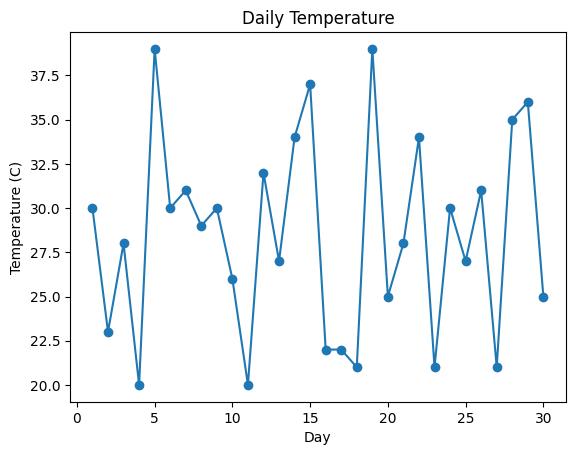

In [31]:
np.random.seed(3)
temps = np.random.randint(20, 40, 30)
days = np.arange(1, 31)
plt.plot(days, temps, marker="o")
plt.title("Daily Temperature")
plt.xlabel("Day")
plt.ylabel("Temperature (C)")
plt.show()

**Q27.** Plot y = sin(x) and y = cos(x) on the same figure for x from 0 to 2π, with a legend.

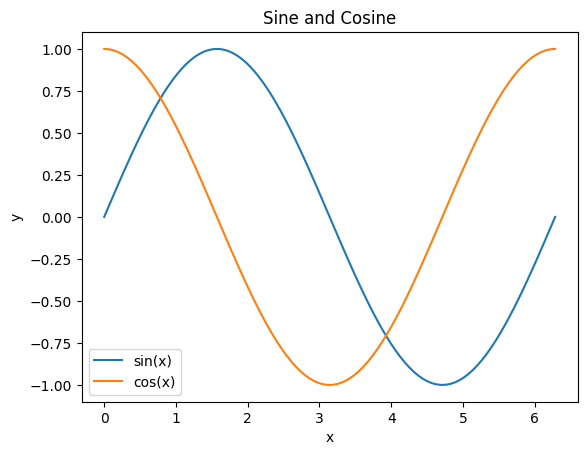

In [32]:
x = np.linspace(0, 2 * np.pi, 100)
plt.plot(x, np.sin(x), label="sin(x)")
plt.plot(x, np.cos(x), label="cos(x)")
plt.title("Sine and Cosine")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

**Q28.** Bar chart comparing the average marks of 4 subjects, with a distinct color for the top subject.

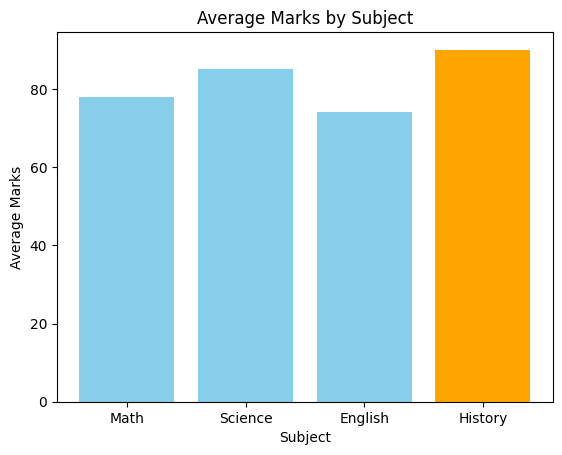

In [33]:
subjects = ["Math", "Science", "English", "History"]
averages = [78, 85, 74, 90]
colors = ["skyblue" if a != max(averages) else "orange" for a in averages]
plt.bar(subjects, averages, color=colors)
plt.title("Average Marks by Subject")
plt.xlabel("Subject")
plt.ylabel("Average Marks")
plt.show()

**Q29.** Histogram of 500 normally distributed random numbers with a vertical line at the mean.

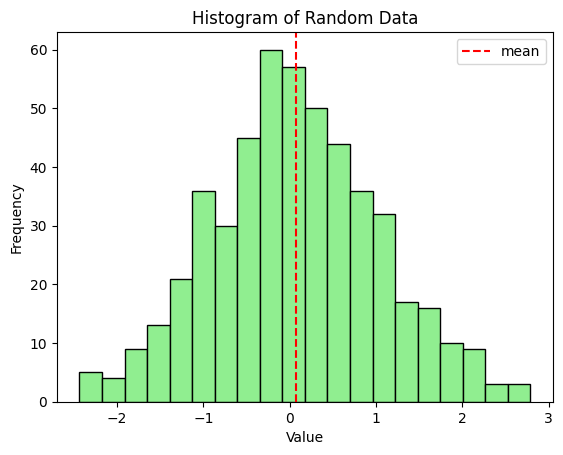

In [34]:
np.random.seed(4)
data = np.random.randn(500)
plt.hist(data, bins=20, color="lightgreen", edgecolor="black")
plt.axvline(data.mean(), color="red", linestyle="--", label="mean")
plt.title("Histogram of Random Data")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.legend()
plt.show()

**Q30.** 2x2 subplot grid showing line, bar, scatter, and histogram charts from the same dataset.

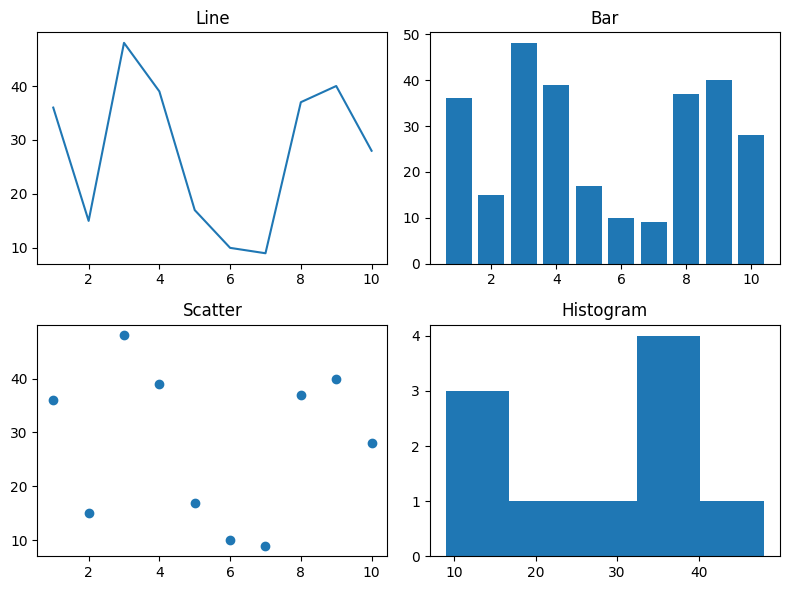

In [35]:
np.random.seed(5)
x = np.arange(1, 11)
y = np.random.randint(1, 50, 10)
fig, ax = plt.subplots(2, 2, figsize=(8, 6))
ax[0, 0].plot(x, y)
ax[0, 0].set_title("Line")
ax[0, 1].bar(x, y)
ax[0, 1].set_title("Bar")
ax[1, 0].scatter(x, y)
ax[1, 0].set_title("Scatter")
ax[1, 1].hist(y, bins=5)
ax[1, 1].set_title("Histogram")
plt.tight_layout()
plt.show()

**Q31.** DataFrame of 6 products (name, price, quantity); add a `total` column as price × quantity.

In [36]:
data = {
    "name": ["Pen", "Notebook", "Bag", "Bottle", "Charger", "Mouse"],
    "price": [2, 5, 25, 8, 15, 12],
    "quantity": [10, 6, 2, 4, 3, 5]
}
df = pd.DataFrame(data)
df["total"] = df["price"] * df["quantity"]
print(df)

       name  price  quantity  total
0       Pen      2        10     20
1  Notebook      5         6     30
2       Bag     25         2     50
3    Bottle      8         4     32
4   Charger     15         3     45
5     Mouse     12         5     60


**Q32.** DataFrame of exam scores across 3 subjects for 10 students; find each student's average and the top performer.

In [37]:
np.random.seed(6)
scores = pd.DataFrame(
    np.random.randint(50, 100, (10, 3)),
    columns=["Math", "Science", "English"]
)
scores["average"] = scores.mean(axis=1)
top_student = scores["average"].idxmax()
print(scores)
print("top performer row:", top_student)

   Math  Science  English    average
0    60       59       85  68.000000
1    70       92       95  85.666667
2    65       92       66  74.333333
3    75       51       61  62.333333
4    63       76       97  78.666667
5    83       94       96  91.000000
6    54       83       58  65.000000
7    52       62       70  61.333333
8    77       81       52  70.000000
9    55       76       65  65.333333
top performer row: 5


**Q33.** DataFrame with `date` and `sales` columns; sort by date and plot sales over time with `.plot()`.

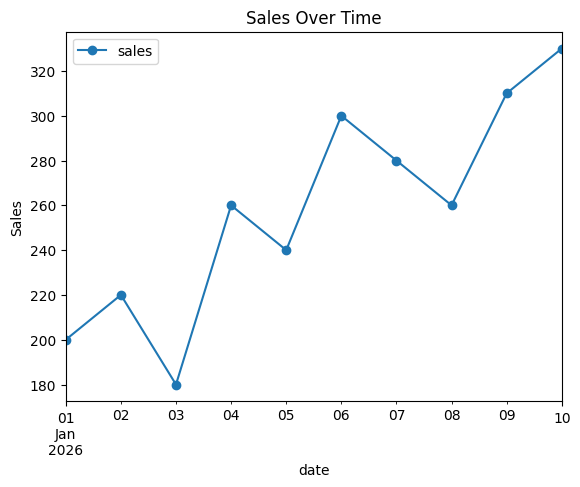

In [38]:
dates = pd.date_range("2026-01-01", periods=10)
sales = [200, 220, 180, 260, 240, 300, 280, 260, 310, 330]
df = pd.DataFrame({"date": dates, "sales": sales}).sample(frac=1, random_state=7)
df = df.sort_values("date")
df.plot(x="date", y="sales", marker="o", title="Sales Over Time")
plt.ylabel("Sales")
plt.show()

**Q34.** DataFrame with missing values in a `score` column; fill with the column mean and confirm no NaNs remain.

In [39]:
df = pd.DataFrame({"name": ["Ali", "Sara", "Omar", "Lina"], "score": [80, None, 90, None]})
df["score"] = df["score"].fillna(df["score"].mean())
print(df)
print("missing values remaining:", df["score"].isna().sum())

   name  score
0   Ali   80.0
1  Sara   85.0
2  Omar   90.0
3  Lina   85.0
missing values remaining: 0


**Q35.** Read a small CSV of monthly expenses, group by category, and plot the totals as a pie chart.

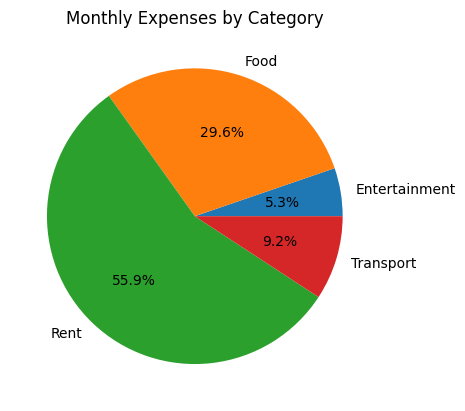

In [40]:
csv_text = """category,amount
Rent,800
Food,300
Food,150
Transport,100
Entertainment,80
Rent,50
Transport,40
"""
with open("expenses.csv", "w") as f:
    f.write(csv_text)
df = pd.read_csv("expenses.csv")
totals = df.groupby("category")["amount"].sum()
plt.pie(totals, labels=totals.index, autopct="%1.1f%%")
plt.title("Monthly Expenses by Category")
plt.show()